# PoC v2 — Notebook centralizado: entrenamiento, comparación y exportación

Clasificador temático de tickets (NLBSE'23, clases `bug`/`feature`/`question`). Este notebook **consolida** todo el flujo de la v1: carga → EDA → preprocesado → TF-IDF+SVM → DistilBERT → comparación → **auto-selección del mejor modelo por F1-macro (test)** → **exportación del ganador** a `backend/artifacts/<name>_<date>_<version>/` con `meta.json`, que el backend FastAPI consume.

> El preprocesado se importa de `common/preprocessing.py` (compartido con el backend) para que entrenamiento e inferencia usen exactamente la misma cadena.

## 1. Bootstrap

In [1]:
REPO_URL = 'https://github.com/elvinsomon/pln-poc-v2.git'

import os, sys, subprocess
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.isdir('/content/pln-poc-v2'):
        subprocess.run(['git', 'clone', REPO_URL, '/content/pln-poc-v2'], check=True)
    os.chdir('/content/pln-poc-v2')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'notebook/requirements.txt'], check=True)
else:
    if os.path.basename(os.getcwd()) == 'notebook':
        os.chdir('..')   # subir a la raíz del proyecto

PROJECT_ROOT = os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import json, random, datetime as dt
from pathlib import Path
import numpy as np
import pandas as pd

from common.preprocessing import build_inference_text
from common.constants import SEED, CLASSES, DEFAULT_PREPROCESS

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); os.environ['PYTHONHASHSEED'] = str(seed)
set_seed()

CFG = {
    'seed': SEED,
    'classes': CLASSES,
    'preprocess': DEFAULT_PREPROCESS,
    'sample_per_class': 10000,
    'val_fraction': 0.1,
    'test_fraction': 0.1,
    'paths': {'raw': 'data/raw/dataset.csv', 'processed': 'data/processed', 'artifacts': 'backend/artifacts'},
    'vectorizer': {'ngram_range': [1, 2], 'min_df': 5, 'max_df': 0.95,
                   'max_features': 100000, 'sublinear_tf': True, 'lowercase': True},
    'classifier': {'C': 1.0, 'loss': 'squared_hinge', 'class_weight': 'balanced', 'max_iter': 5000},
    'bert': {'model_name': 'distilbert-base-uncased', 'max_length': 256, 'batch_size': 32,
             'epochs': 3, 'learning_rate': 2e-5, 'weight_decay': 0.01, 'warmup_ratio': 0.1, 'fp16': True},
}
labels = CFG['classes']
print('PROJECT_ROOT:', PROJECT_ROOT, '| IN_COLAB:', IN_COLAB)

PROJECT_ROOT: /Users/elvinsomon/Documents/US/2doCuatrimestre/Procesamiento del Lenguaje Natural (PLN)/Tarea02/pln-poc-v2 | IN_COLAB: False


## 2. Carga del dataset + filtrado

> Coloca el CSV de NLBSE'23 en `data/raw/dataset.csv` (o monta Drive en Colab y apunta `CFG['paths']['raw']` a esa ruta). Se filtran las 3 clases objetivo (se descarta `documentation`).

In [2]:
RAW = Path(CFG['paths']['raw'])
COLUMNS = ['id', 'labels', 'title', 'body', 'author_association']
DTYPES = {'id': 'int64', 'labels': 'category', 'title': 'string', 'body': 'string', 'author_association': 'category'}

df = pd.read_csv(RAW, usecols=COLUMNS, dtype=DTYPES, low_memory=False)
df = df[df['labels'].isin(CFG['classes'])].copy()
df['labels'] = df['labels'].astype(str)
print('filas tras filtrar:', len(df))
print(df['labels'].value_counts())

filas tras filtrar: 1219215
labels
bug         670951
feature     472216
question     76048
Name: count, dtype: int64


## 3. EDA breve

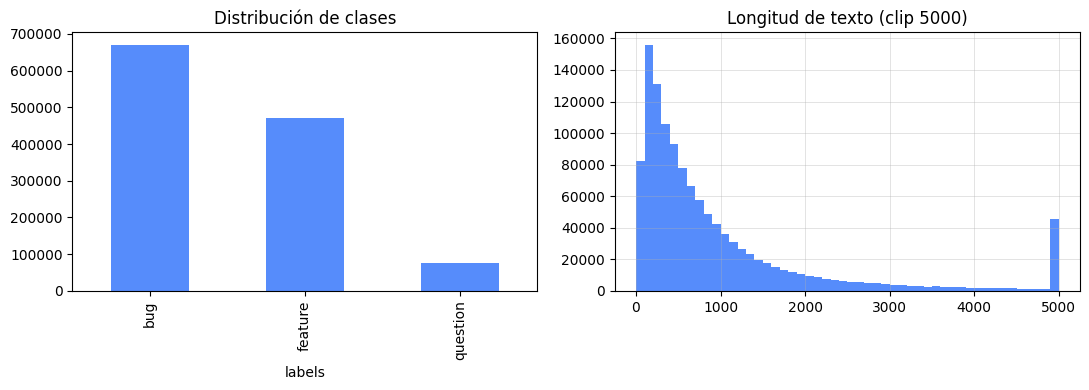

mediana de longitud por clase:
labels
bug         765.0
feature     336.0
question    644.0
Name: raw_len, dtype: Float64


In [3]:
import matplotlib.pyplot as plt

df['raw_len'] = (df['title'].fillna('') + ' ' + df['body'].fillna('')).str.len()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df['labels'].value_counts().plot(kind='bar', ax=axes[0], title='Distribución de clases')
df['raw_len'].clip(upper=5000).hist(bins=50, ax=axes[1]); axes[1].set_title('Longitud de texto (clip 5000)')
plt.tight_layout(); plt.show()
print('mediana de longitud por clase:'); print(df.groupby('labels')['raw_len'].median())

## 4. Preprocesado + splits balanceados

Misma cadena que usará el backend (`build_inference_text`): combina título+cuerpo → anonimiza (emails/URLs/handles) → limpia (code/markdown/whitespace) → trunca a 5000 chars. Luego muestreo balanceado y hold-out estratificado.

In [ ]:
from sklearn.model_selection import train_test_split

proc = Path(CFG['paths']['processed']); proc.mkdir(parents=True, exist_ok=True)
split_paths = {n: proc / f'{n}.parquet' for n in ('train', 'val', 'test')}

# Idempotente: si los splits ya existen, se cargan (no se vuelve a preprocesar
# ni a splitear). Borra data/processed/*.parquet para regenerar desde cero.
if all(p.exists() for p in split_paths.values()):
    splits = {n: pd.read_parquet(p) for n, p in split_paths.items()}
    print('splits existentes cargados (sin regenerar):')
else:
    pre = CFG['preprocess']
    df['text'] = [build_inference_text(t, b, pre) for t, b in zip(df['title'], df['body'])]
    data = df[df['text'].str.len() > 0][['text', 'labels']].rename(columns={'labels': 'label'}).reset_index(drop=True)

    parts = [g.sample(min(CFG['sample_per_class'], len(g)), random_state=CFG['seed']) for _, g in data.groupby('label')]
    data = pd.concat(parts).sample(frac=1.0, random_state=CFG['seed']).reset_index(drop=True)

    train_val, test = train_test_split(data, test_size=CFG['test_fraction'], stratify=data['label'], random_state=CFG['seed'])
    rel_val = CFG['val_fraction'] / (1.0 - CFG['test_fraction'])
    train, val = train_test_split(train_val, test_size=rel_val, stratify=train_val['label'], random_state=CFG['seed'])
    splits = {'train': train.reset_index(drop=True), 'val': val.reset_index(drop=True), 'test': test.reset_index(drop=True)}

    for name, d in splits.items():
        d.to_parquet(split_paths[name], index=False)
    print('splits generados y guardados:')

for name, d in splits.items():
    print(f'{name:5s} n={len(d):>6,}  {d["label"].value_counts().to_dict()}')

## 5. Métricas (helper) + suelo majority

In [5]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.dummy import DummyClassifier

def compute_metrics(y_true, y_pred, labels):
    y_true = np.asarray(list(y_true)); y_pred = np.asarray(list(y_pred))
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'f1_macro': float(f1_score(y_true, y_pred, average='macro', labels=labels, zero_division=0)),
        'f1_per_class': dict(zip(labels, [float(x) for x in f1_score(y_true, y_pred, average=None, labels=labels, zero_division=0)])),
        'confusion_matrix': {'labels': labels, 'matrix': confusion_matrix(y_true, y_pred, labels=labels).tolist()},
        'report': classification_report(y_true, y_pred, labels=labels, digits=4, zero_division=0),
    }

dummy = DummyClassifier(strategy='most_frequent', random_state=CFG['seed']).fit(splits['train']['text'], splits['train']['label'])
majority_metrics = compute_metrics(splits['test']['label'], dummy.predict(splits['test']['text']), labels)
print('Majority (suelo) · f1_macro test:', round(majority_metrics['f1_macro'], 4))

Majority (suelo) · f1_macro test: 0.1667


## 6. TF-IDF + LinearSVC (Candidato A)

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

v, c = CFG['vectorizer'], CFG['classifier']
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=tuple(v['ngram_range']), min_df=v['min_df'], max_df=v['max_df'],
                              max_features=v['max_features'], sublinear_tf=v['sublinear_tf'], lowercase=v['lowercase'])),
    ('svm', LinearSVC(C=c['C'], loss=c['loss'], class_weight=c['class_weight'],
                      max_iter=c['max_iter'], random_state=CFG['seed'])),
])
svm_pipeline.fit(splits['train']['text'], splits['train']['label'])
svm_metrics = {
    'val':  compute_metrics(splits['val']['label'],  svm_pipeline.predict(splits['val']['text']),  labels),
    'test': compute_metrics(splits['test']['label'], svm_pipeline.predict(splits['test']['text']), labels),
}
print('TF-IDF+SVM · f1_macro test:', round(svm_metrics['test']['f1_macro'], 4))

TF-IDF+SVM · f1_macro test: 0.7909


## 7. DistilBERT fine-tuning (Candidato B)

Requiere GPU (Colab T4, ~6-8 min). Si no hay GPU, se omite automáticamente y el SVM será el ganador.

In [ ]:
import importlib.util
HAS_TORCH = importlib.util.find_spec('torch') is not None

bert_model, bert_metrics = None, None

if not HAS_TORCH:
    print('torch no instalado -> se omite BERT; ganará el SVM.')
else:
    import tempfile
    import torch
    from transformers import (AutoModelForSequenceClassification, AutoTokenizer,
                              DataCollatorWithPadding, Trainer, TrainingArguments, set_seed as hf_set_seed)
    from datasets import Dataset

    def detect_device():
        if torch.cuda.is_available():
            return 'cuda'
        if getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
            return 'mps'
        return 'cpu'

    class BertClassifier:
        def __init__(self, cfg):
            self.cfg = cfg; b = cfg['bert']
            self.classes = list(cfg['classes'])
            self.label2id = {c: i for i, c in enumerate(self.classes)}
            self.id2label = {i: c for c, i in self.label2id.items()}
            self.model_name = b['model_name']; self.max_length = b['max_length']
            self.batch_size = b['batch_size']; self.seed = cfg['seed']
            self.device = detect_device(); self.tokenizer = None; self.model = None
        def fit(self, texts, labels):
            hf_set_seed(self.seed)
            self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
            self.model = AutoModelForSequenceClassification.from_pretrained(
                self.model_name, num_labels=len(self.classes), id2label=self.id2label, label2id=self.label2id)
            y = [self.label2id[str(v)] for v in list(labels)]
            ds = Dataset.from_dict({'text': [str(t) for t in list(texts)], 'labels': y})
            ds = ds.map(lambda bb: self.tokenizer(bb['text'], truncation=True, max_length=self.max_length),
                        batched=True, remove_columns=['text'])
            b = self.cfg['bert']
            # output_dir: directorio temporal escribible en cualquier entorno (Colab/local).
            # save_strategy='no' => no se guarda nada importante ahí; el modelo se persiste con .save().
            args = TrainingArguments(
                output_dir=tempfile.mkdtemp(prefix='bert_trainer_'), num_train_epochs=b['epochs'],
                per_device_train_batch_size=self.batch_size, per_device_eval_batch_size=self.batch_size,
                learning_rate=float(b['learning_rate']), weight_decay=b['weight_decay'], warmup_ratio=b['warmup_ratio'],
                fp16=(self.device == 'cuda' and b.get('fp16', True)), eval_strategy='no', save_strategy='no',
                logging_steps=50, report_to='none', seed=self.seed)
            Trainer(model=self.model, args=args, train_dataset=ds,
                    data_collator=DataCollatorWithPadding(self.tokenizer)).train()
            self.model.to(self.device).eval(); return self
        def predict_proba(self, texts):
            texts = [str(t) for t in list(texts)]; self.model.to(self.device).eval(); out = []
            with torch.no_grad():
                for i in range(0, len(texts), self.batch_size):
                    enc = self.tokenizer(texts[i:i + self.batch_size], truncation=True, padding=True,
                                         max_length=self.max_length, return_tensors='pt').to(self.device)
                    out.append(torch.softmax(self.model(**enc).logits, dim=-1).cpu().numpy())
            return np.concatenate(out, axis=0)
        def predict(self, texts):
            ids = self.predict_proba(texts).argmax(axis=1)
            return np.array([self.id2label[int(i)] for i in ids])
        def save(self, d):
            d = Path(d); d.mkdir(parents=True, exist_ok=True)
            self.model.save_pretrained(d); self.tokenizer.save_pretrained(d)
            (d / 'label_map.json').write_text(json.dumps({'classes': self.classes, 'label2id': self.label2id},
                                              ensure_ascii=False, indent=2), encoding='utf-8')
            return d

    dev = detect_device()
    if dev == 'cpu':
        print('AVISO: device=cpu (sin GPU). El fine-tuning sería inviable; se omite BERT y ganará el SVM.')
    else:
        if dev == 'mps':
            print('device=mps (Apple Silicon): entrena, pero más lento que una GPU CUDA. Reduce epochs si tarda demasiado.')
        bert_model = BertClassifier(CFG).fit(splits['train']['text'], splits['train']['label'])
        bert_metrics = {'test': compute_metrics(splits['test']['label'], bert_model.predict(splits['test']['text']), labels)}
        print('DistilBERT · f1_macro test:', round(bert_metrics['test']['f1_macro'], 4))

device=mps (Apple Silicon): entrena, pero más lento que una GPU CUDA. Reduce epochs si tarda demasiado.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/24000 [00:00<?, ? examples/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/Users/elvinsomon/Documents/US/2doCuatrimestre/Procesamiento del Lenguaje Natural (PLN)/Tarea02/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
50,1.090720


## 8. Comparación de modelos (test)

In [ ]:
rows = [('Majority', majority_metrics), ('TF-IDF+SVM', svm_metrics['test'])]
if bert_metrics:
    rows.append(('DistilBERT', bert_metrics['test']))
comp = pd.DataFrame([{'modelo': n, 'accuracy': m['accuracy'], 'f1_macro': m['f1_macro'],
                      **{f'f1_{cl}': m['f1_per_class'][cl] for cl in labels}} for n, m in rows]).set_index('modelo').round(4)
print(comp)
if bert_metrics:
    delta = bert_metrics['test']['f1_macro'] - svm_metrics['test']['f1_macro']
    print(f'Δ f1_macro (BERT - SVM): {delta:+.4f}')

## 9. Auto-selección del ganador (mayor F1-macro en test)

In [ ]:
candidates = {'tfidf_svm': (svm_pipeline, svm_metrics['test'], 'sklearn')}
if bert_metrics:
    candidates['distilbert'] = (bert_model, bert_metrics['test'], 'bert')

winner = max(candidates, key=lambda k: candidates[k][1]['f1_macro'])
w_model, w_metrics, w_type = candidates[winner]
svm_f1 = svm_metrics['test']['f1_macro']
if bert_metrics:
    bert_f1 = bert_metrics['test']['f1_macro']
    reason = (f"Ganador '{winner}': test f1_macro {w_metrics['f1_macro']:.4f}. "
              f"SVM {svm_f1:.4f} vs BERT {bert_f1:.4f} (Δ {bert_f1 - svm_f1:+.4f}).")
else:
    reason = f"Ganador '{winner}' (único candidato no trivial): test f1_macro {w_metrics['f1_macro']:.4f}. BERT omitido (sin GPU)."
print('tipo:', w_type)
print(reason)

## 10. Exportación del ganador (artefacto versionado + meta.json + active.json)

In [ ]:
today = dt.date.today().isoformat()
version = 'v1'
artifact = f'{winner}_{today}_{version}'
art_root = Path(CFG['paths']['artifacts'])
adir = art_root / artifact
adir.mkdir(parents=True, exist_ok=True)

meta = {
    'schema_version': 1, 'name': winner, 'type': w_type, 'version': version,
    'created_date': today,
    'created_at': dt.datetime.now(dt.timezone.utc).strftime('%Y-%m-%dT%H:%M:%SZ'),
    'classes': labels, 'preprocessing': CFG['preprocess'], 'seed': CFG['seed'],
    'metrics': {'test': {'accuracy': w_metrics['accuracy'], 'f1_macro': w_metrics['f1_macro'],
                         'f1_per_class': w_metrics['f1_per_class']}},
    'selected_reason': reason,
}
if w_type == 'sklearn':
    import joblib
    joblib.dump(w_model, adir / 'model.joblib')
    meta['files'] = {'model': 'model.joblib'}
else:
    w_model.save(adir)   # escribe HF model+tokenizer + label_map.json
    meta['files'] = {'model_dir': '.', 'label_map': 'label_map.json'}
    meta['bert'] = {'model_name': CFG['bert']['model_name'], 'max_length': CFG['bert']['max_length']}

(adir / 'meta.json').write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding='utf-8')
(art_root / 'active.json').write_text(json.dumps({'active': artifact, 'updated_at': meta['created_at']},
                                      ensure_ascii=False, indent=2), encoding='utf-8')
print('artefacto exportado ->', adir)
print('active.json apunta a ->', artifact)

## 11. Sanidad del preprocesado + nota de despliegue

In [ ]:
# El backend usa meta['preprocessing']; verificamos que produce el MISMO texto
# que CFG['preprocess'] usado en entrenamiento (evita drift de preprocesado).
row = df.iloc[min(10, len(df) - 1)]
t_train = build_inference_text(row['title'], row['body'], CFG['preprocess'])
t_serve = build_inference_text(row['title'], row['body'], meta['preprocessing'])
assert t_train == t_serve, 'El preprocesado del meta.json difiere del de entrenamiento'
print('OK: preprocesado consistente entrenamiento <-> meta.json')
print('ejemplo texto servido:', t_serve[:160])

## 12. Despliegue del backend

1. **Si entrenaste en Colab:** descarga (zip) la carpeta `backend/artifacts/<artifact>/` y el `backend/artifacts/active.json`, y colócalos bajo el `pln-poc-v2/backend/artifacts/` local. El artefacto BERT pesa ~270 MB.
2. Desde la raíz `pln-poc-v2/`:
   ```bash
   python -m venv .venv && source .venv/bin/activate
   pip install -r backend/requirements.txt   # borra torch/transformers si el ganador es sklearn
   uvicorn backend.main:app --reload
   ```
3. Prueba: `GET /health`, `POST /predict`, `POST /tickets`, `GET /tickets` (orden Alta→Media→Baja, FIFO por fecha).